In [1]:
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation
from gymnasium.wrappers import ResizeObservation
import ale_py
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from agent import Agent
from memories import *

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion() # interactive on

nbFrameStack = 4

In [3]:
env = gym.make("ALE/Qbert-v5", obs_type="grayscale")
print(env.observation_space.shape)
env = ResizeObservation(env, (84, 84)) 
print(env.observation_space.shape)
env = FrameStackObservation(env, stack_size=nbFrameStack)

(210, 160)
(84, 84)


## Hyperparameters for dueling, no Double learning

In [4]:
BATCH_SIZE = 32
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.01
EPS_DECAY = 100000
TAU = 0.005
LR = 6.25e-5
REPLAY_BUFFER_SIZE = 100000
trainingFrequency = 4
nbActions = env.action_space.n


In [5]:
def trainModel(num_episodes = 600, numGameAVG = 5, doubleMode = False, nStep = 1, weightName = "Model") :
  finalScore = []

  for game in range(numGameAVG) :
    finalGameScore = []
    
    agent = Agent(n_FrameStack=nbFrameStack, n_actions=nbActions, lr=LR, gamma=GAMMA, tau=TAU, device=device,
                   epsDecay=EPS_DECAY, epsEnd=EPS_END, epsStart=EPS_START,use_double_dqn=doubleMode, 
                   )
    memoryBuffer = ReplayMemory(REPLAY_BUFFER_SIZE)

    for i_episode in range(num_episodes):
      nStepMemory = SmallMemory(nStep, GAMMA)

      currentGameScore = 0

      if i_episode == 0:
        state, info = env.reset(seed=game)
      else :
        state, info = env.reset()
      #state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0) /255.0
      state = torch.tensor(state, dtype=torch.uint8).unsqueeze(0)

      for t in count():
          action = agent.select_action(state)
          observation, reward, terminated, truncated, _ = env.step(action)

          currentGameScore += reward

          #reward_tensor = torch.tensor([reward/100.0], device=device)
          #next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0) /255.0
          reward_tensor = torch.tensor([reward/100.0], dtype=torch.float32)
          next_state = torch.tensor(observation, dtype=torch.uint8).unsqueeze(0)
          done = terminated or truncated

          prevTrans = nStepMemory.push(state, action, next_state, reward_tensor, done)

          if prevTrans is not None :
            # Store the transition in memory
            memoryBuffer.push(*prevTrans)
            
          # Move to the next state
          state = next_state

          # Perform one step of the optimization (on the policy network)
          if agent.numberStep % trainingFrequency == 0:

            agent.optimizeModel(memoryBuffer, batch_size=BATCH_SIZE, nStep=nStep)

            # Soft update of the target network's weights
            # θ′ ← τ θ + (1 −τ )θ′
            agent.softUpdateNetwork()

          if done :
              lastMoves = nStepMemory.flush()
              for transitions in lastMoves:
                  memoryBuffer.push(*transitions)

              finalGameScore.append(currentGameScore)
              break
      print(f"Episode n°{i_episode}")
      print(f"reward : {currentGameScore}")
      print(f"Number of steps : {t + 1}")
      print("=" *20)

    finalScore.append(finalGameScore)

  torch.save(agent.onlineNetwork.state_dict(), weightName)
  return finalScore

Episode n°0
reward : 200.0
Number of steps : 380
Episode n°1
reward : 0.0
Number of steps : 287
Episode n°2
reward : 475.0
Number of steps : 381
Episode n°3
reward : 175.0
Number of steps : 321
Episode n°4
reward : 125.0
Number of steps : 316
Episode n°5
reward : 50.0
Number of steps : 271
Episode n°6
reward : 125.0
Number of steps : 323
Episode n°7
reward : 125.0
Number of steps : 369
Episode n°8
reward : 0.0
Number of steps : 285
Episode n°9
reward : 125.0
Number of steps : 352
Episode n°10
reward : 0.0
Number of steps : 279
Episode n°11
reward : 75.0
Number of steps : 341
Episode n°12
reward : 150.0
Number of steps : 320
Episode n°13
reward : 50.0
Number of steps : 327
Episode n°14
reward : 225.0
Number of steps : 325
Episode n°15
reward : 100.0
Number of steps : 336
Episode n°16
reward : 200.0
Number of steps : 365
Episode n°17
reward : 275.0
Number of steps : 435
Episode n°18
reward : 0.0
Number of steps : 285
Episode n°19
reward : 75.0
Number of steps : 316
Episode n°20
reward : 

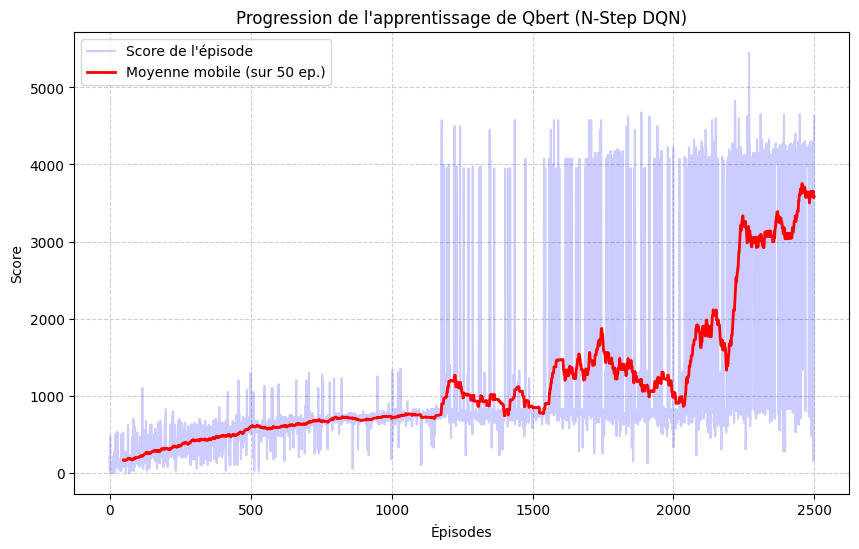

In [ ]:
finalScore = trainModel(3000, 1, doubleMode=True, nStep=3, weightName="DoubleQbert3-Step.pth")

# 2. On récupère la liste des scores de la première (et unique) run
scores_bruts = finalScore[0] 

df_scores = pd.DataFrame({
    "Episode": range(len(scores_bruts)),
    "Reward": scores_bruts
})

nom_fichier_csv = "scores_DoubleQbert3-Step.csv"
df_scores.to_csv(nom_fichier_csv, index=False)


# 3. On calcule la moyenne mobile sur une fenêtre (ex: 50 épisodes)
fenetre = 50
scores_lisses = pd.Series(scores_bruts).rolling(window=fenetre).mean()

# 4. On crée un beau graphique
plt.figure(figsize=(10, 6)) 


# On trace les scores bruts en arrière-plan (très transparent) pour voir la variance
plt.plot(scores_bruts, alpha=0.2, color='blue', label='Score de l\'épisode')

# On trace la courbe lissée par-dessus, bien visible
plt.plot(scores_lisses, color='red', linewidth=2, label=f'Moyenne mobile (sur {fenetre} ep.)')

plt.title("Progression de l'apprentissage de Qbert (N-Step DQN)")
plt.xlabel("Épisodes")
plt.ylabel("Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()